In [64]:
import xmitgcm
import cmaps

ds = xmitgcm.open_mdsdataset(data_dir='./input/output/', grid_dir='./input', prefix=['surf','state','pollutant_fluxes','pollutant_surface','pollutant_state'], delta_t=900)
ds

/home/rugkey/miniconda3/envs/MITgcm/lib/python3.12/site-packages/xmitgcm/mds_store.py:289: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds['time'] = xr.decode_cf(ds[['time']])['time']
/home/rugkey/miniconda3/envs/MITgcm/lib/python3.12/site-packages/xmitgcm/mds_store.py:289: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presenc

<xarray.Dataset> Size: 3GB
Dimensions:   (XC: 180, YC: 80, XG: 180, YG: 80, Z: 40, Zp1: 41, Zu: 40,
               Zl: 40, time: 56)
Coordinates: (12/34)
  * XC        (XC) >f4 720B 1.0 3.0 5.0 7.0 9.0 ... 353.0 355.0 357.0 359.0
  * YC        (YC) >f4 320B -79.0 -77.0 -75.0 -73.0 ... 73.0 75.0 77.0 79.0
  * XG        (XG) >f4 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * YG        (YG) >f4 320B -80.0 -78.0 -76.0 -74.0 ... 72.0 74.0 76.0 78.0
  * Z         (Z) >f4 160B -5.01 -15.07 -25.28 ... -5.125e+03 -5.375e+03
  * Zp1       (Zp1) >f4 164B 0.0 -10.04 -20.17 ... -5e+03 -5.25e+03 -5.625e+03
    ...        ...
    dyF       (YC, XC) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    dyU       (YG, XG) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    rhoRef    (Z) >f4 160B dask.array<chunksize=(40,), meta=np.ndarray>
    dxF       (YC, XC) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    dxV       (YG, XG) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    iter      (time) int64 448B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables: (12/21)
    ETAN      (time, YC, XC) float32 3MB dask.array<chunksize=(1, 80, 180), meta=np.ndarray>
    UVEL      (time, Z, YC, XG) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    VVEL      (time, Z, YG, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    THETA     (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    SALT      (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_S  (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    ...        ...
    POLCSNK   (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    TRAC01    (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLSURF   (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLGMASS  (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLGSRC   (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLGSNK   (time, Z, YC, XC) float32 129MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='./input/outpu...

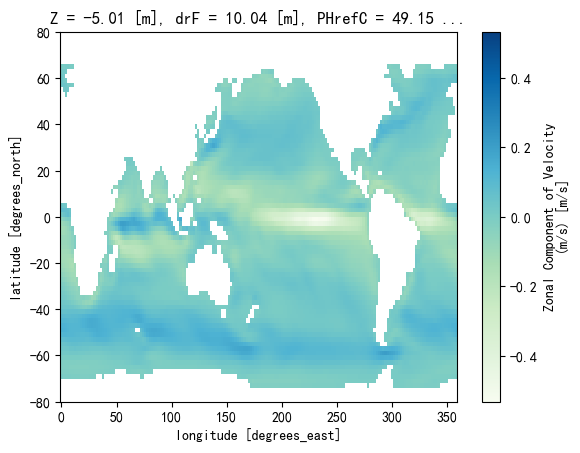

In [2]:
import numpy as np
#u向流速
ds.UVEL.where(ds.UVEL!=0)[-1, 0].plot(cmap='GnBu')

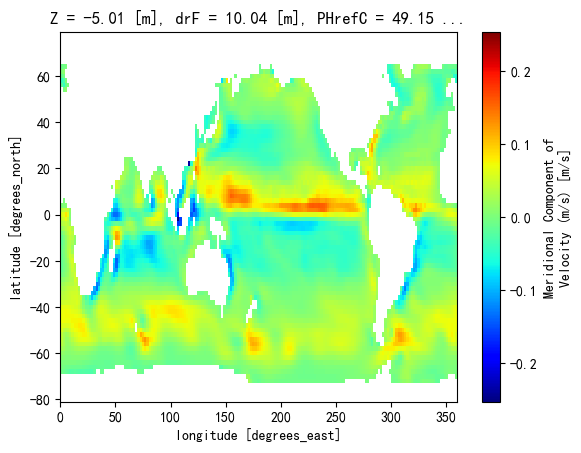

In [3]:
import numpy as np
#v向速度
ds.VVEL.where(ds.VVEL!=0)[-1, 0].plot(cmap='jet')

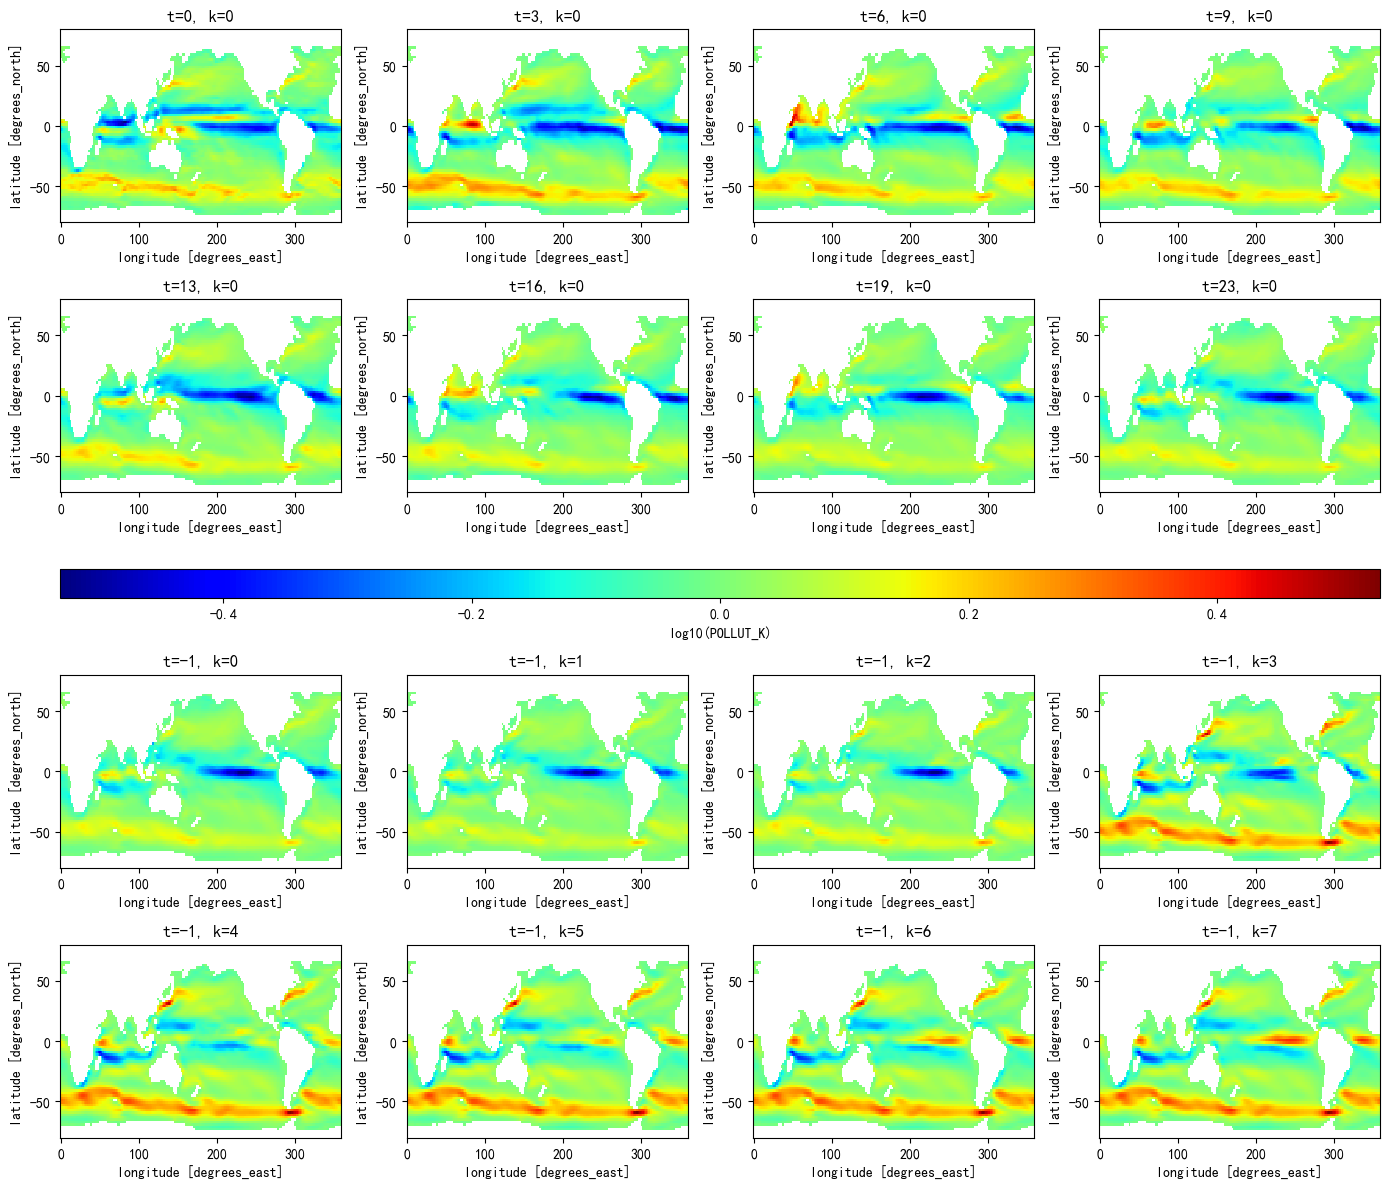

In [4]:
#流速
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.UVEL.where(ds.UVEL!=0)
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    im = da.plot(ax=ax, add_colorbar=False, cmap='jet')
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da.plot(ax=ax, add_colorbar=False, cmap='jet')
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLLUT_K)")

plt.tight_layout()
plt.show()


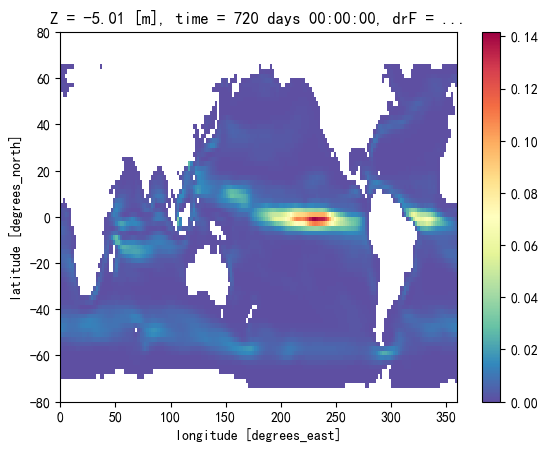

In [5]:
#uv速度结合，需要统一网格到同一点上
import xgcm
grid = xgcm.Grid(ds, periodic=['X','Y'])

ke = 0.5 * (grid.interp((ds.UVEL*ds.hFacW)**2, 'X') + grid.interp((ds.VVEL*ds.hFacS)**2, 'Y'))
ke[-1,0].where(ds.maskC[0]).plot(cmap='Spectral_r')

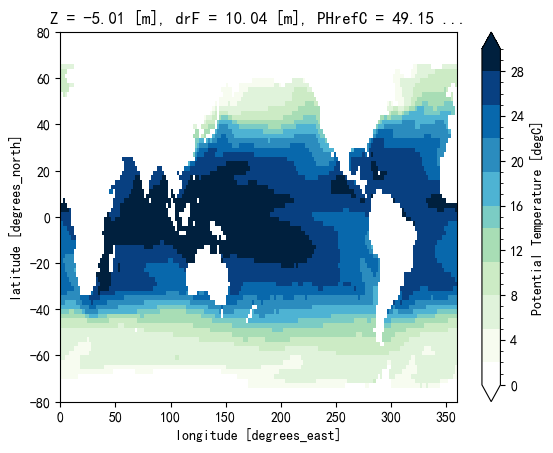

In [6]:
import numpy as np
import cmaps
#温度
ds.THETA.where(ds.THETA!=0)[-1, 0].plot(cmap=cmaps.CBR_wet,levels=np.linspace(0,30,31))

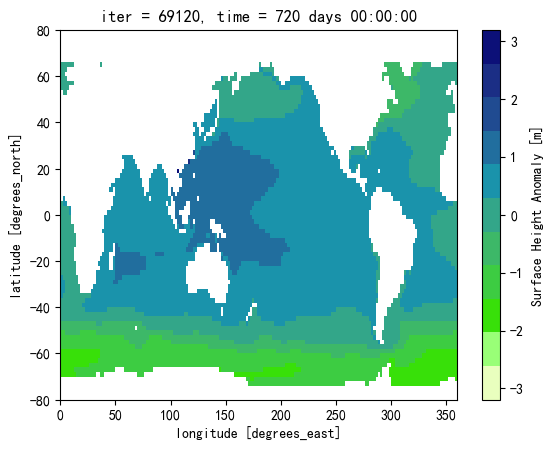

In [7]:
import numpy as np
#自由海面高度
ds.ETAN.where(ds.ETAN!=0)[-1].plot(cmap=cmaps.GSFC_landsat_udf_density)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

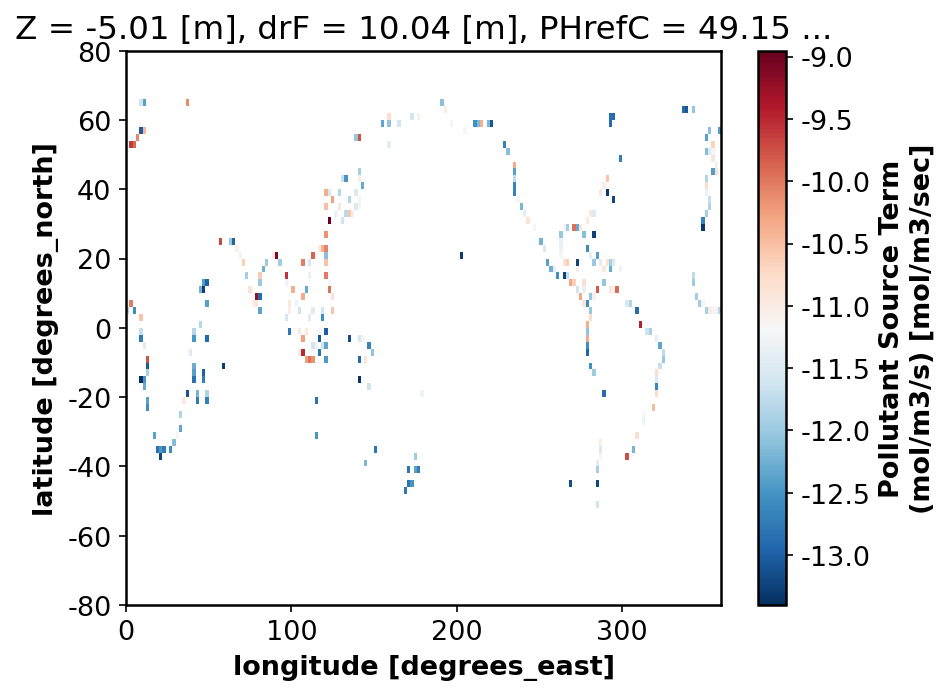

In [65]:
import numpy as np
import xarray as xr
#局部源项 (`mol/m^3/s`)
da = ds.POLLUT_S[-1, 0]
da_log = np.log10(da.where(da > 0))
da_log.plot(cmap='RdBu_r')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

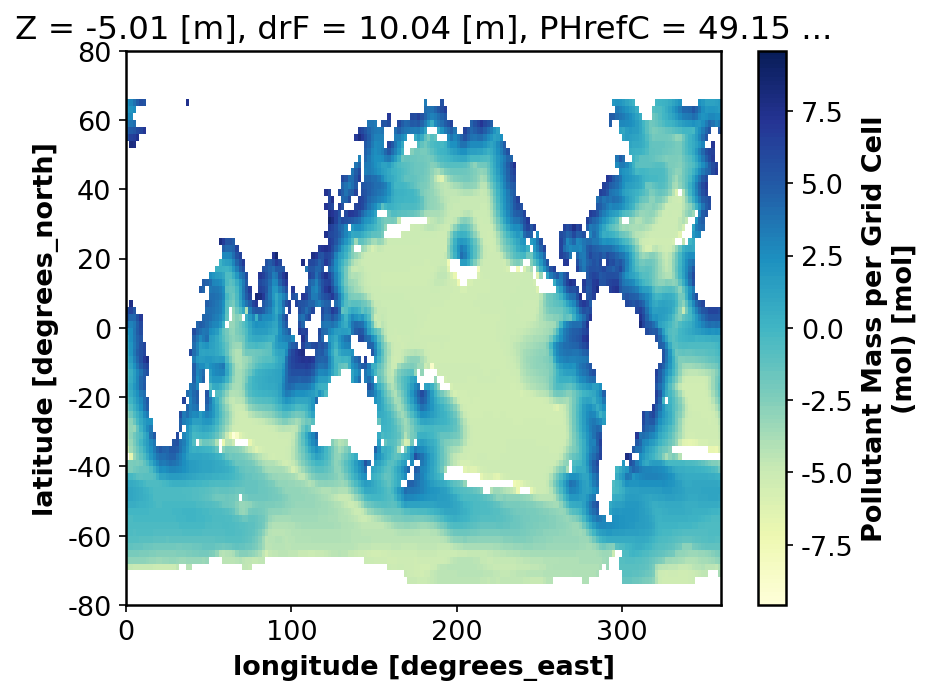

In [66]:
import numpy as np
import xarray as xr

da = ds.POLLUT_M[-1, 0]
da_log = np.log10(da.where(da > 0))
da_log.plot(cmap=cmaps.MPL_YlGnBu)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

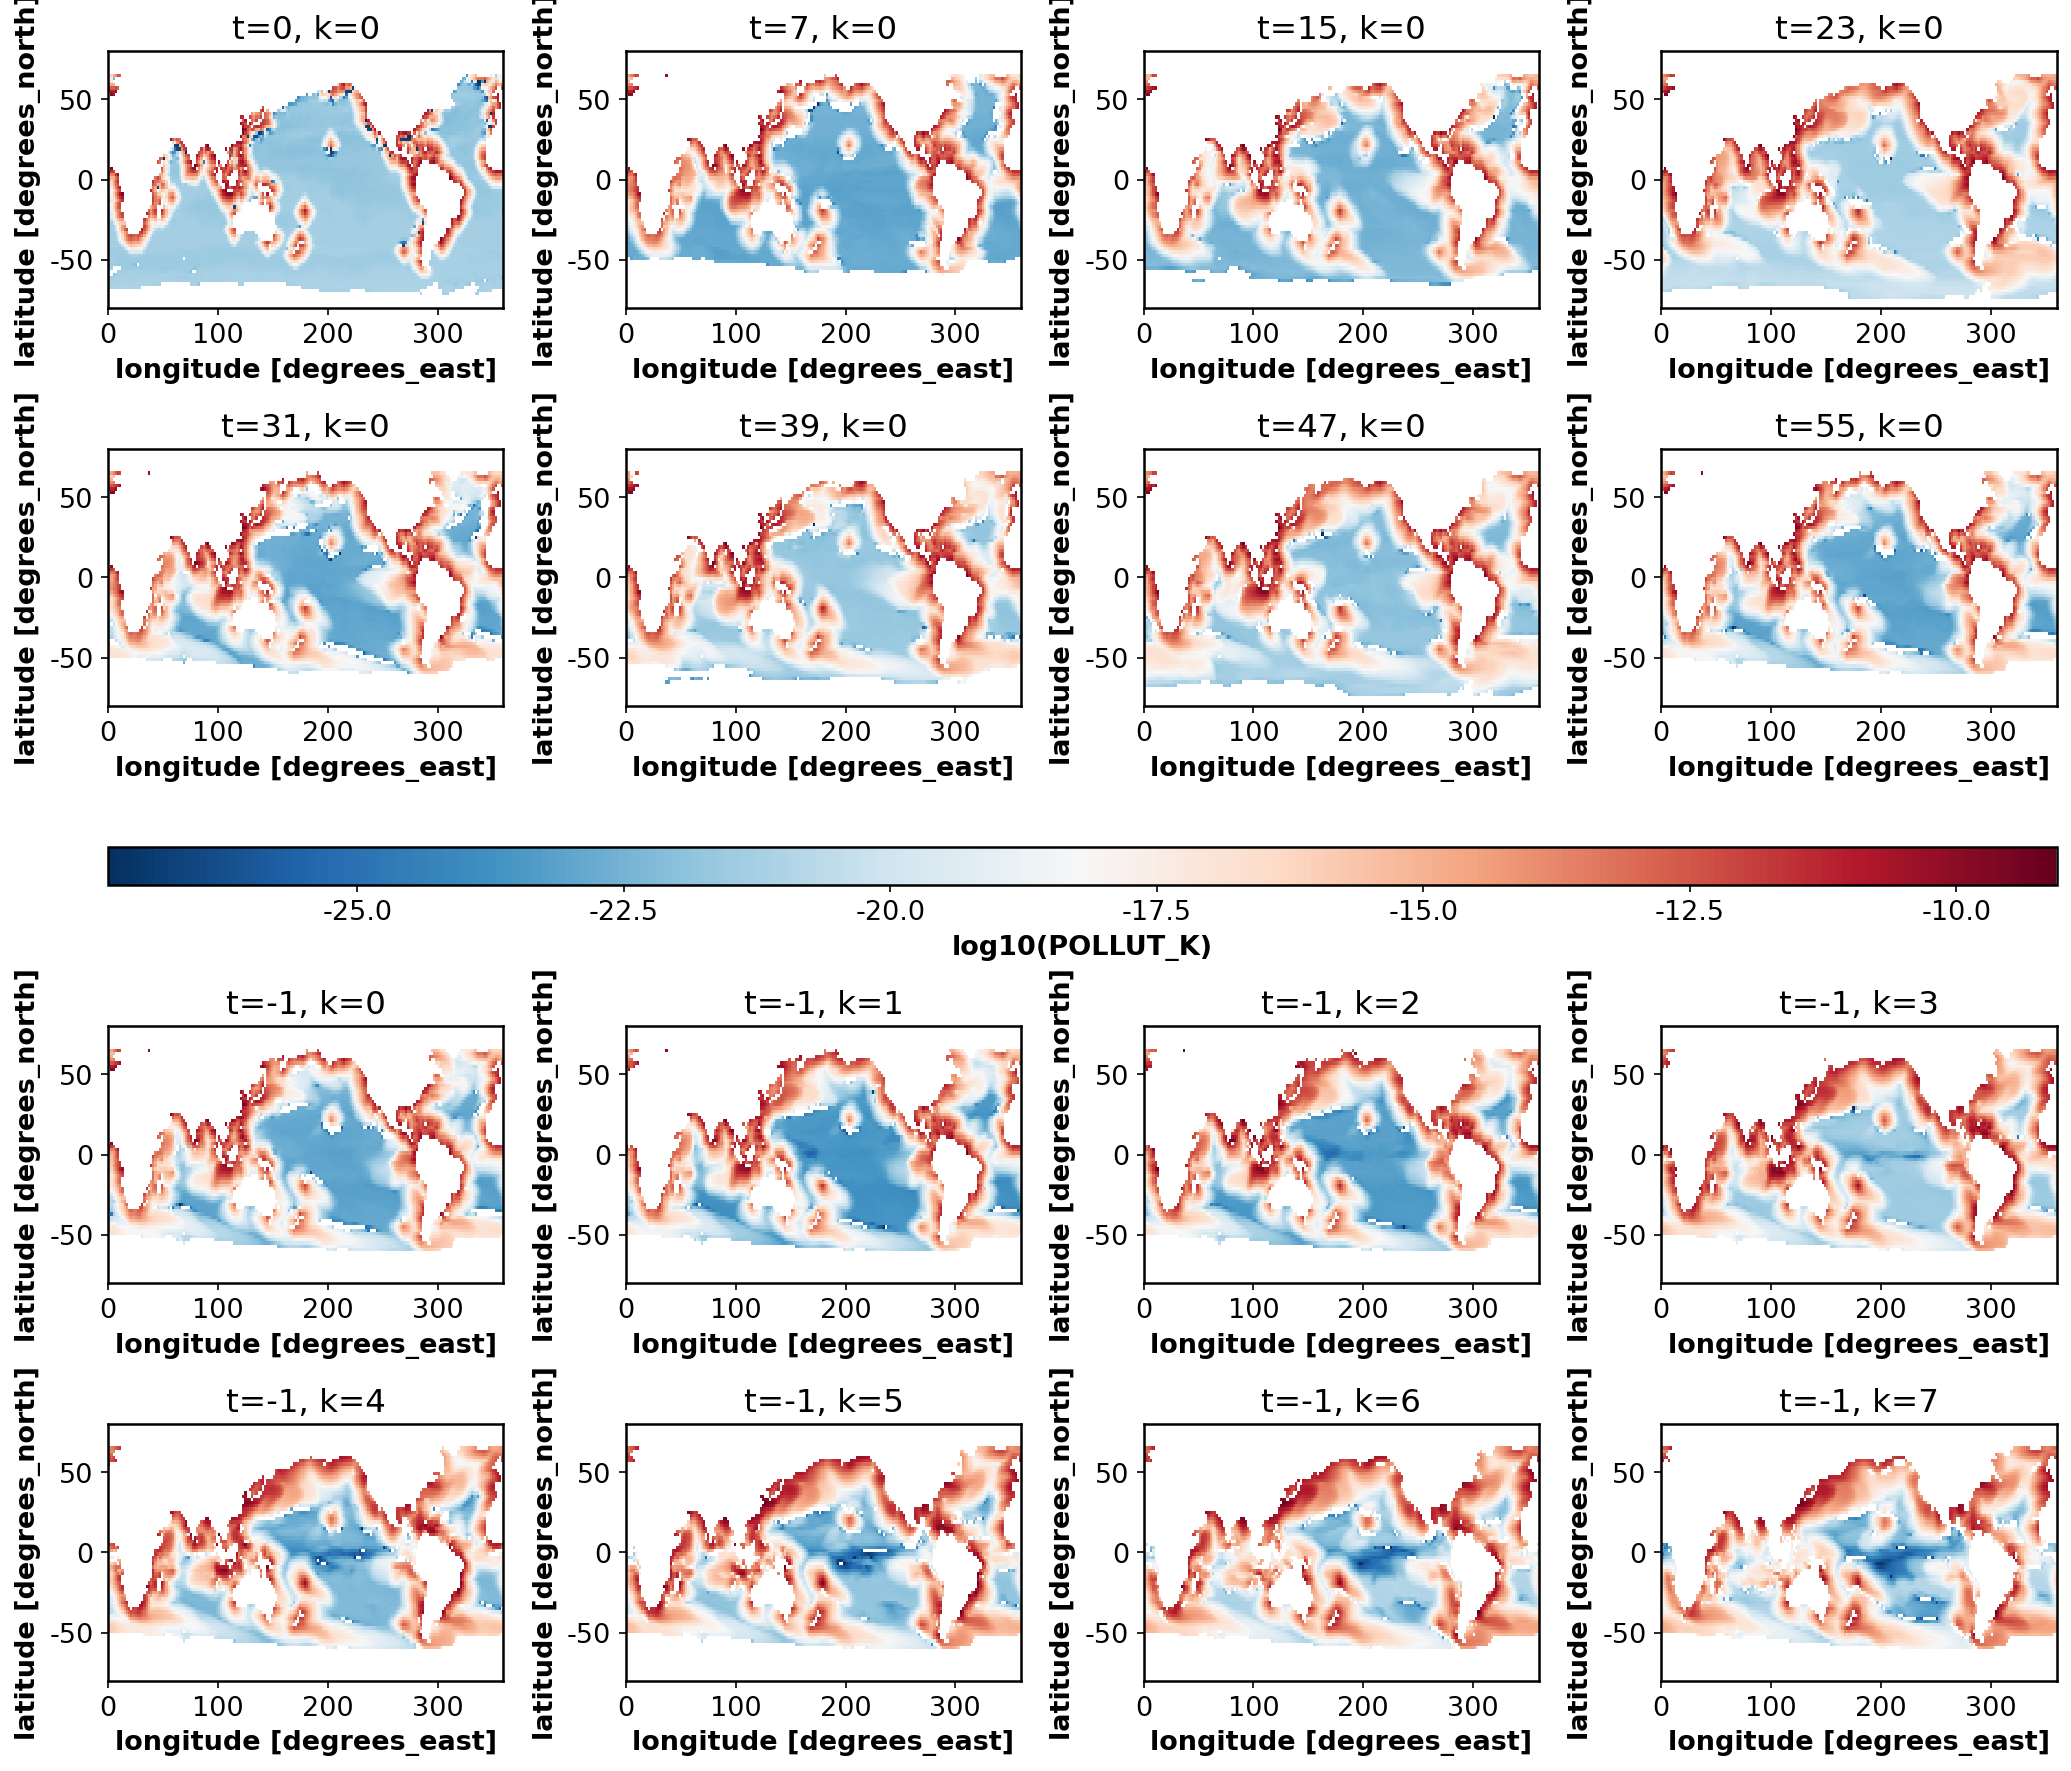

In [67]:
#局部总汇项 (`mol/m^3/s`)
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.POLLUT_K
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap='RdBu_r')
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap='RdBu_r')
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLLUT_K)")

plt.tight_layout()
plt.show()


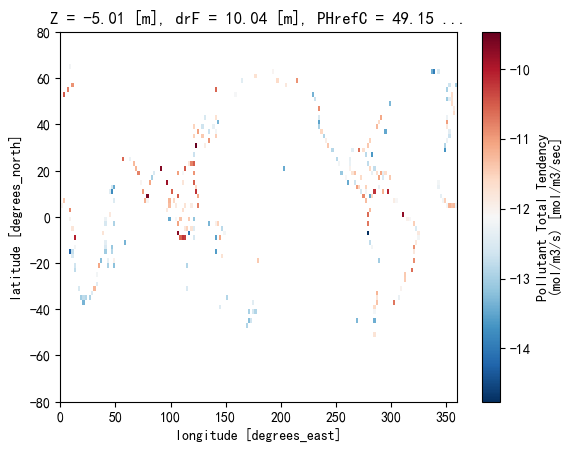

In [30]:
#局部净趋势 (= 源 − 汇, `mol/m^3/s`)
import numpy as np
import xarray as xr
da = ds.POLLUT_T[-1, 0]
da_log = np.log10(da.where(da > 0))
da_log.plot(cmap='RdBu_r')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

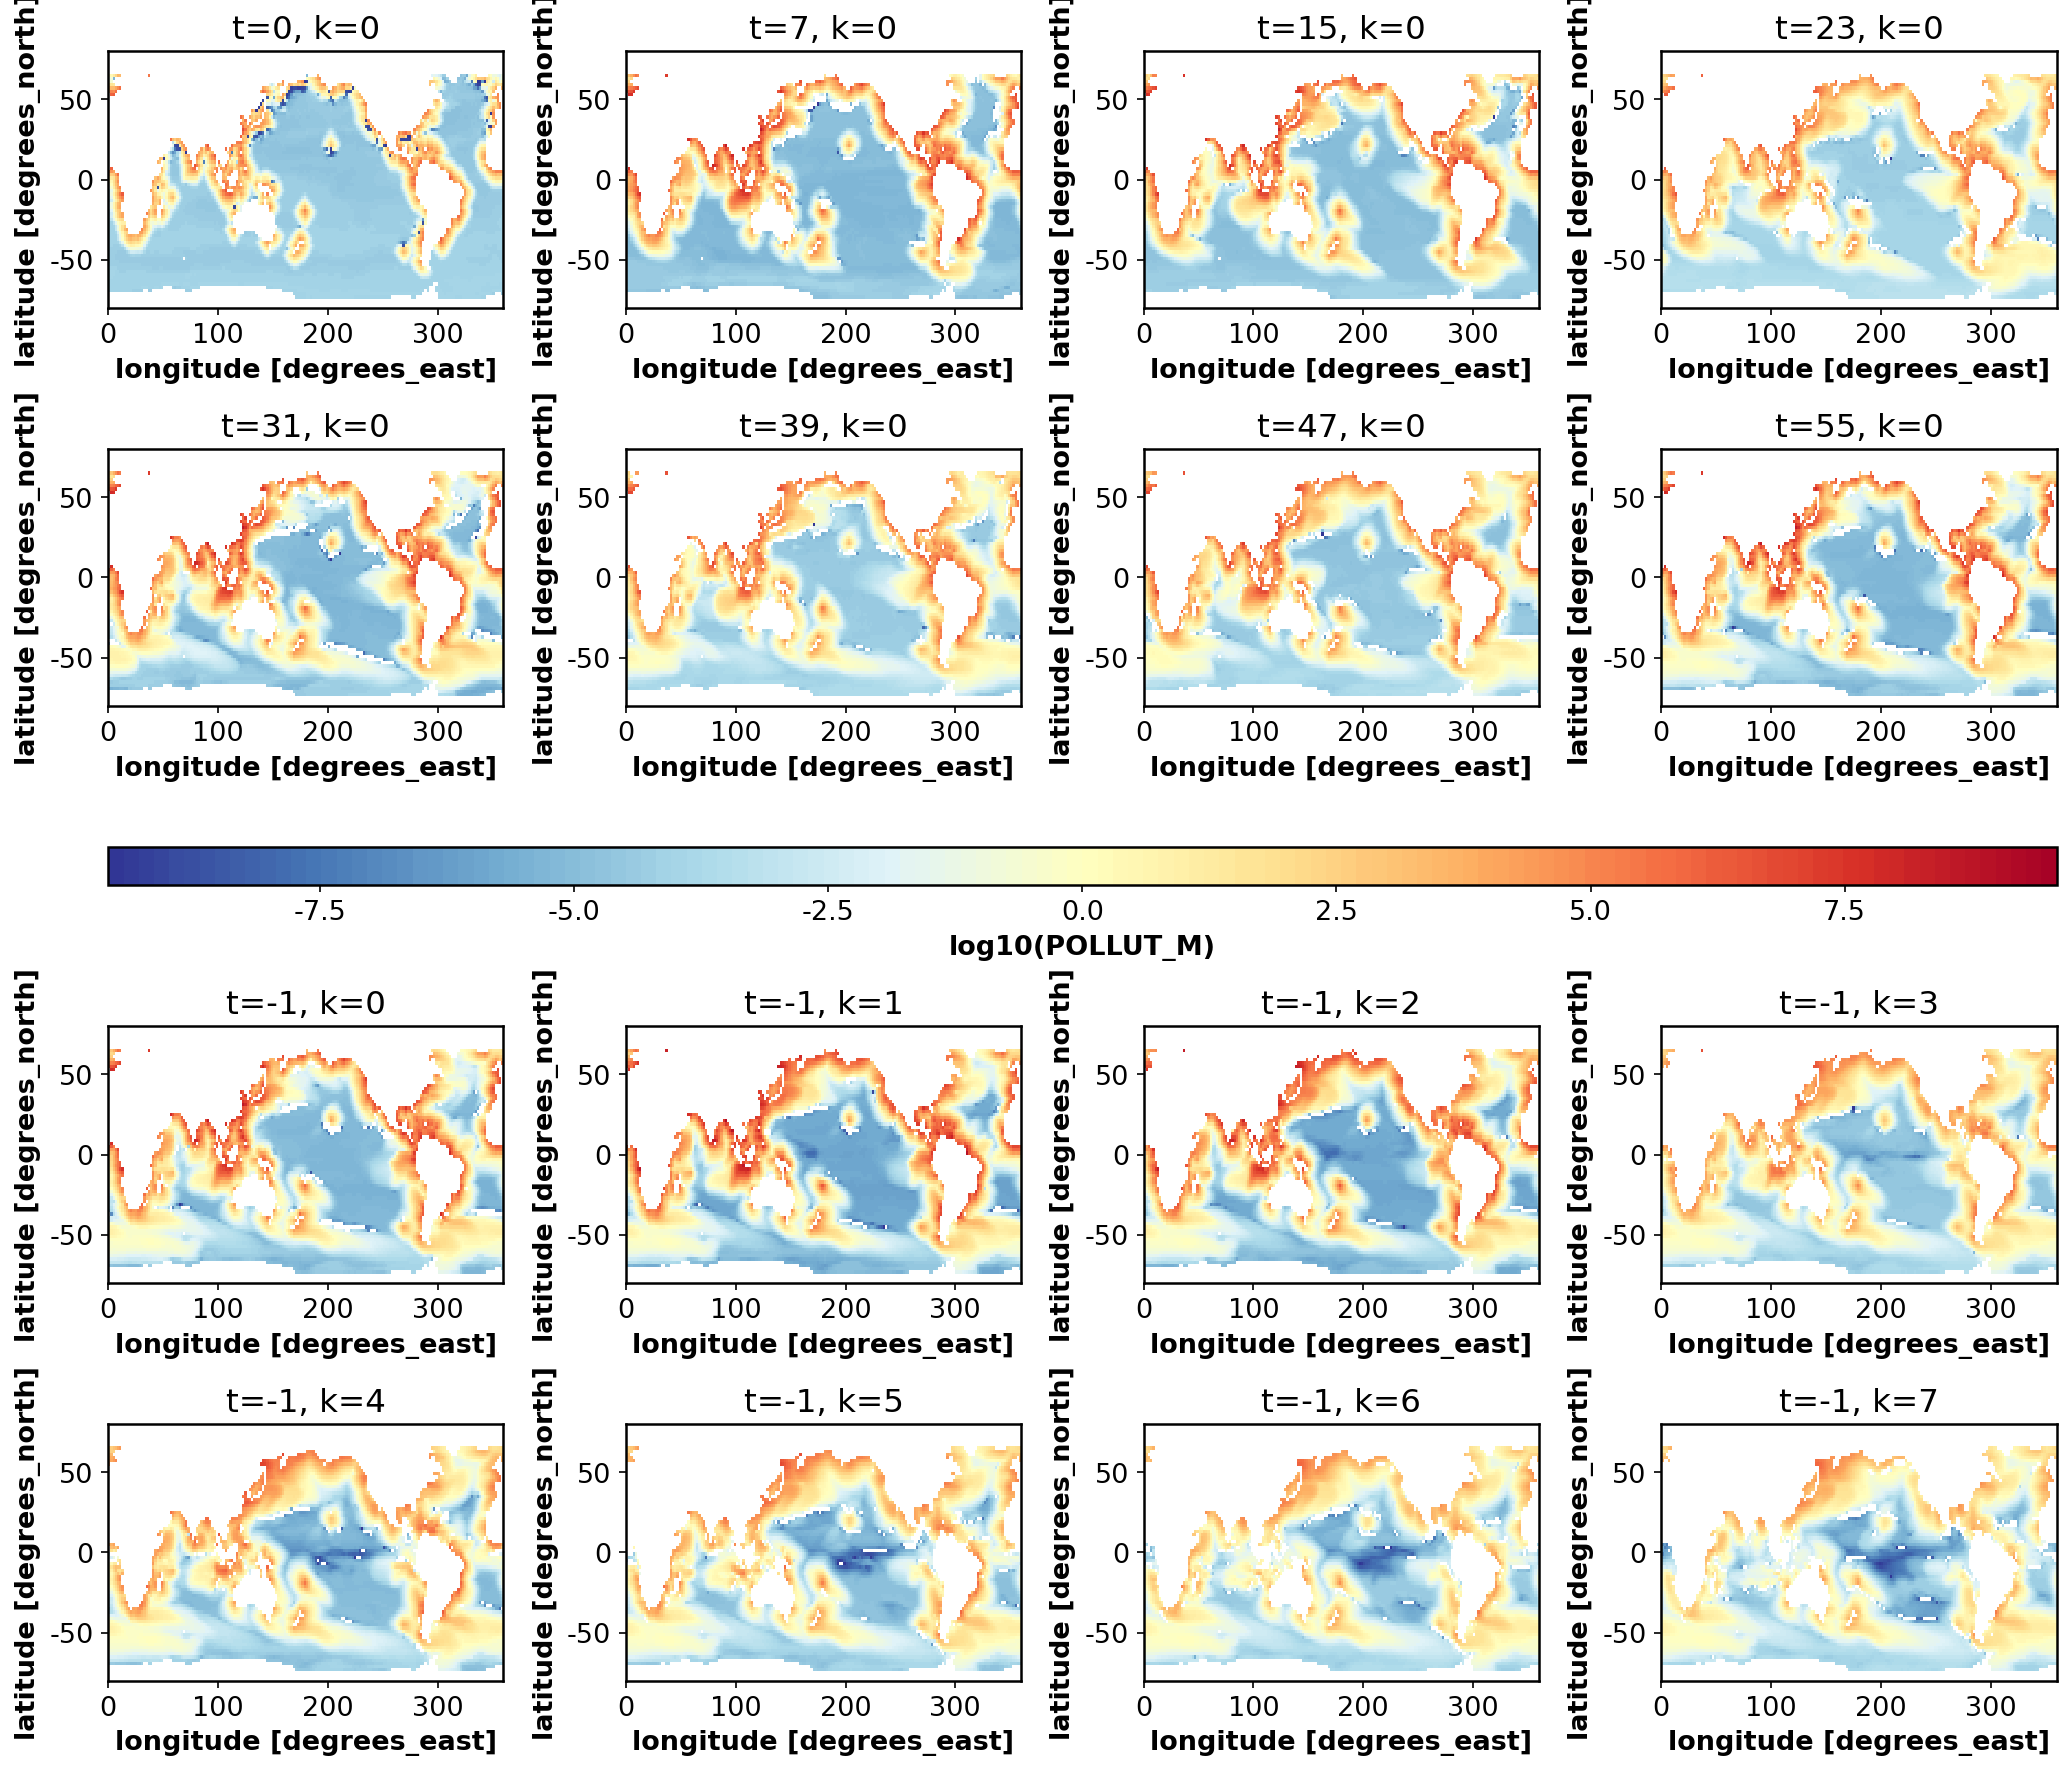

In [68]:
#单元质量 (`mol`)
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.POLLUT_M
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.MPL_RdYlBu_r)
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.MPL_RdYlBu_r)
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLLUT_M)")

plt.tight_layout()
plt.show()


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

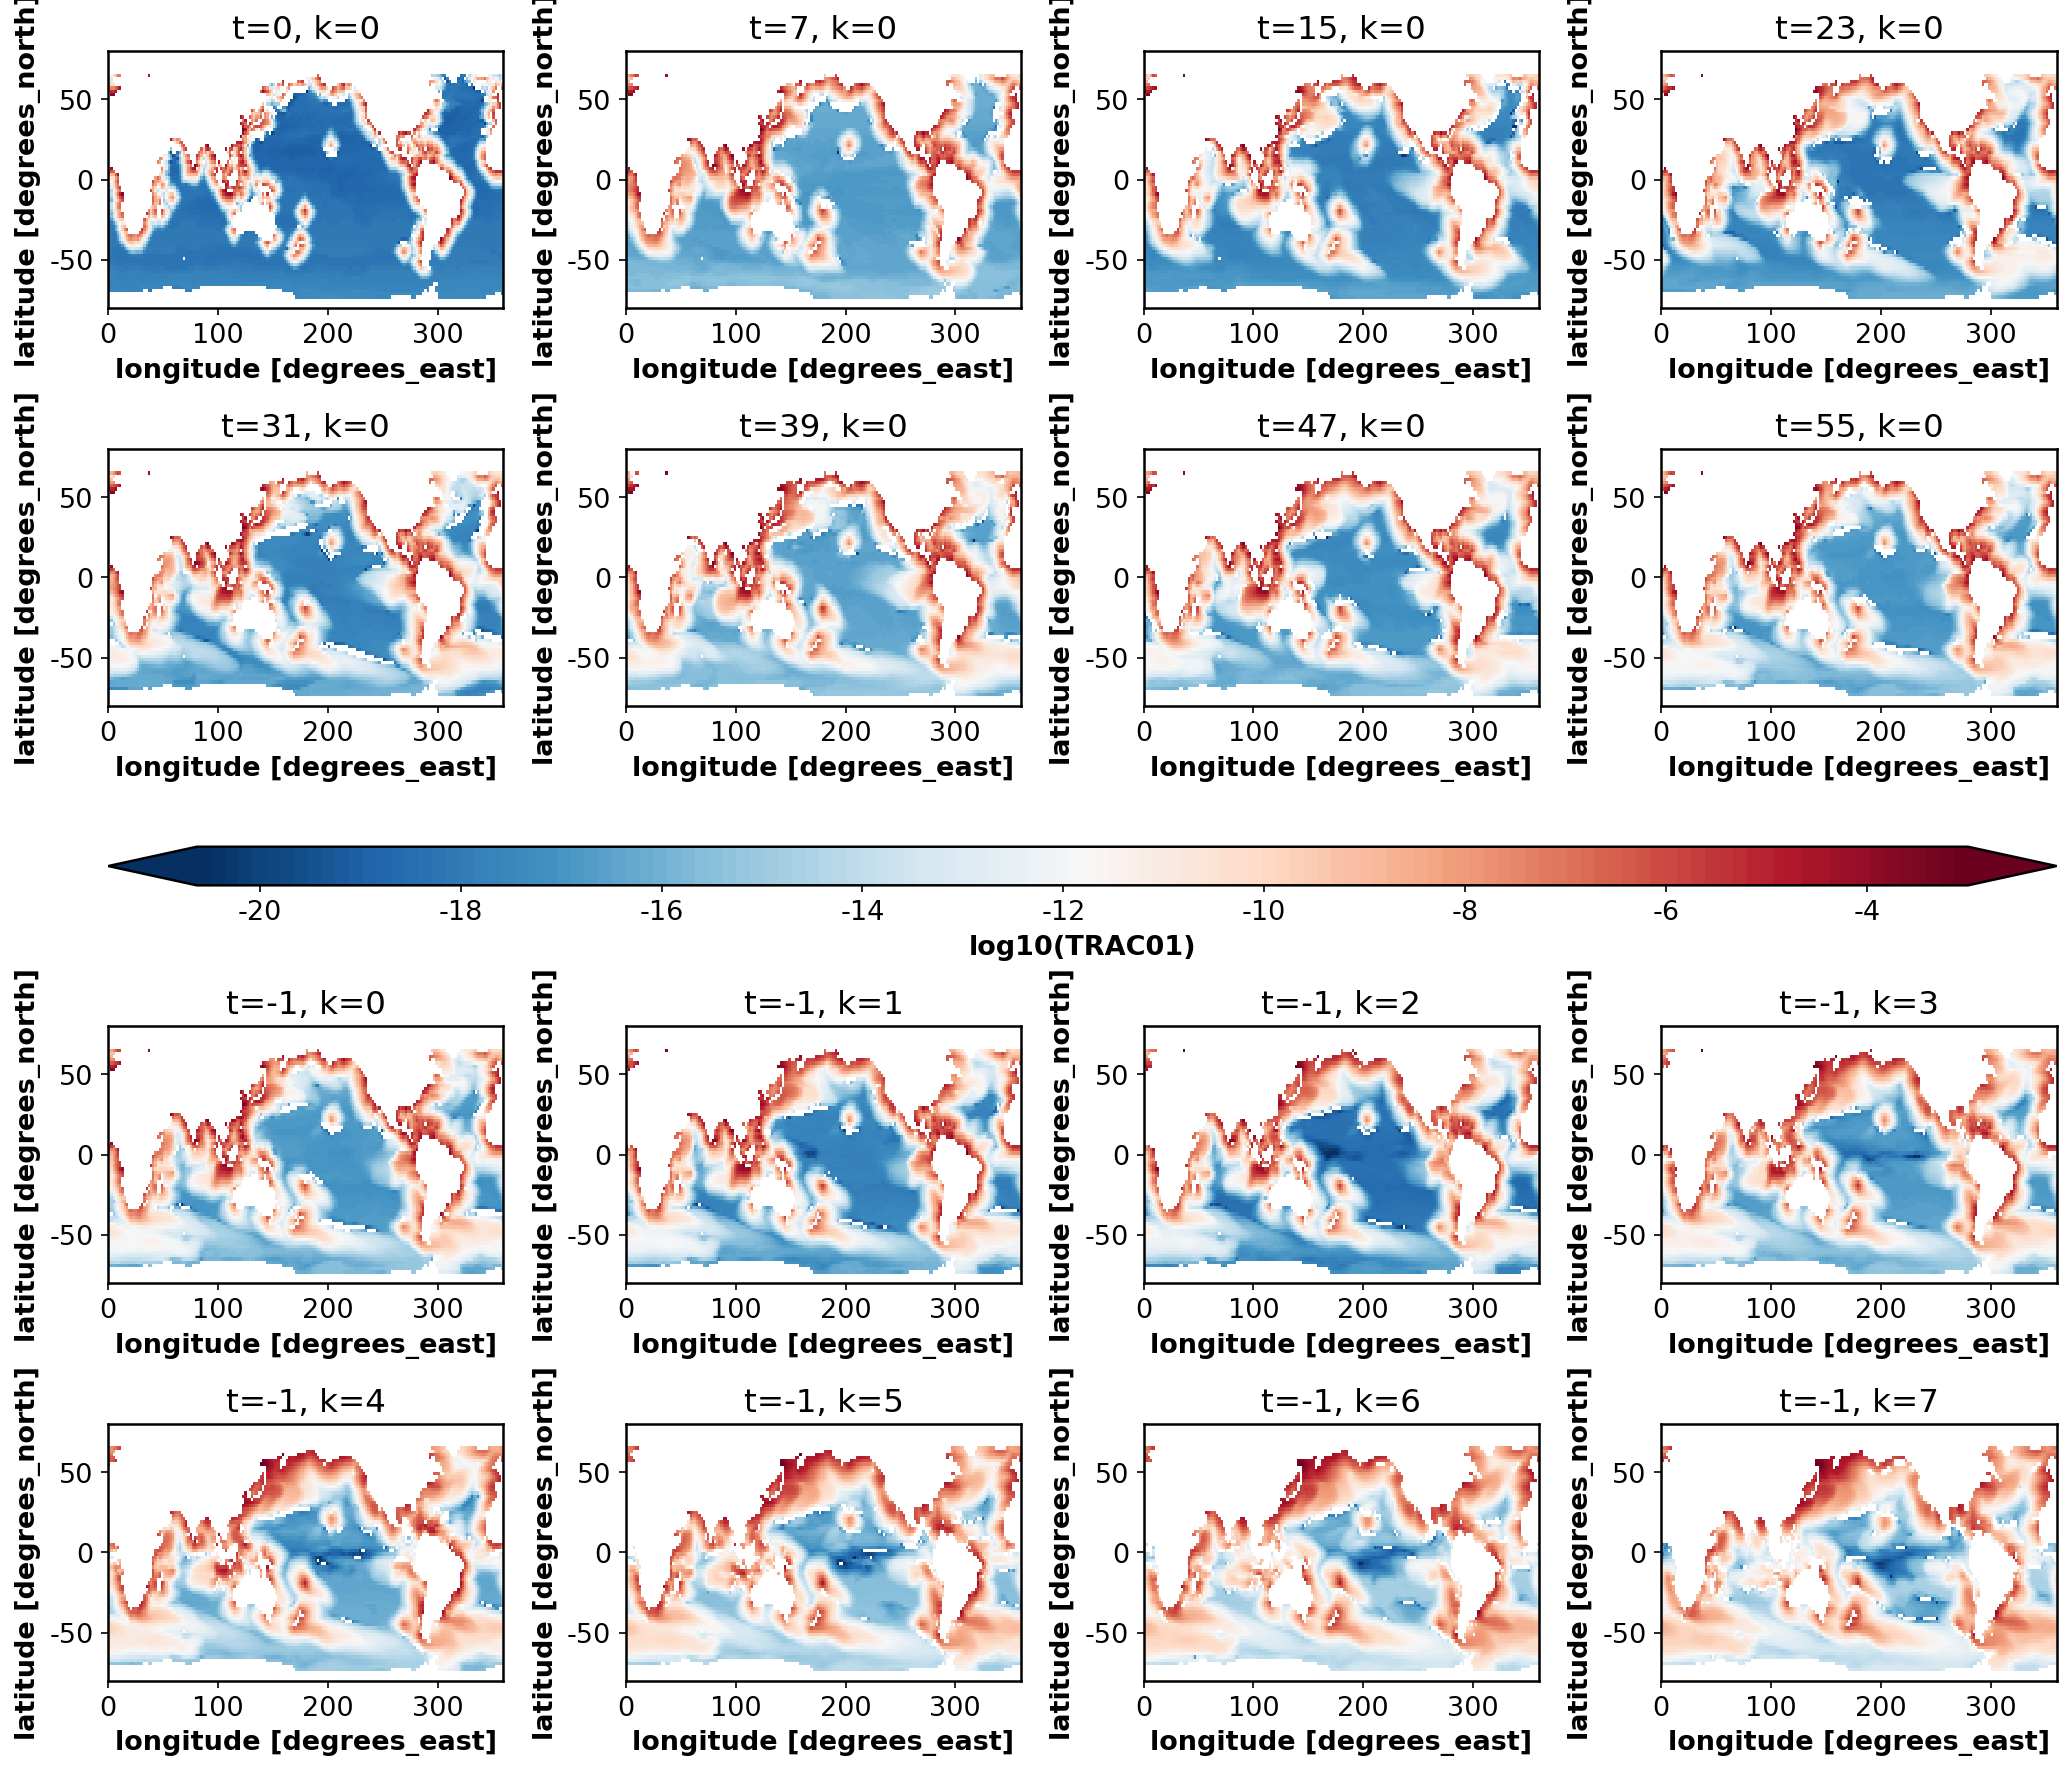

In [69]:
#污染物浓度场 (`mol/m^3`)
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.TRAC01
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.MPL_RdBu_r)
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.MPL_RdBu_r)
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal',extend='both')
cbar.set_label("log10(TRAC01)")

plt.tight_layout()
plt.show()


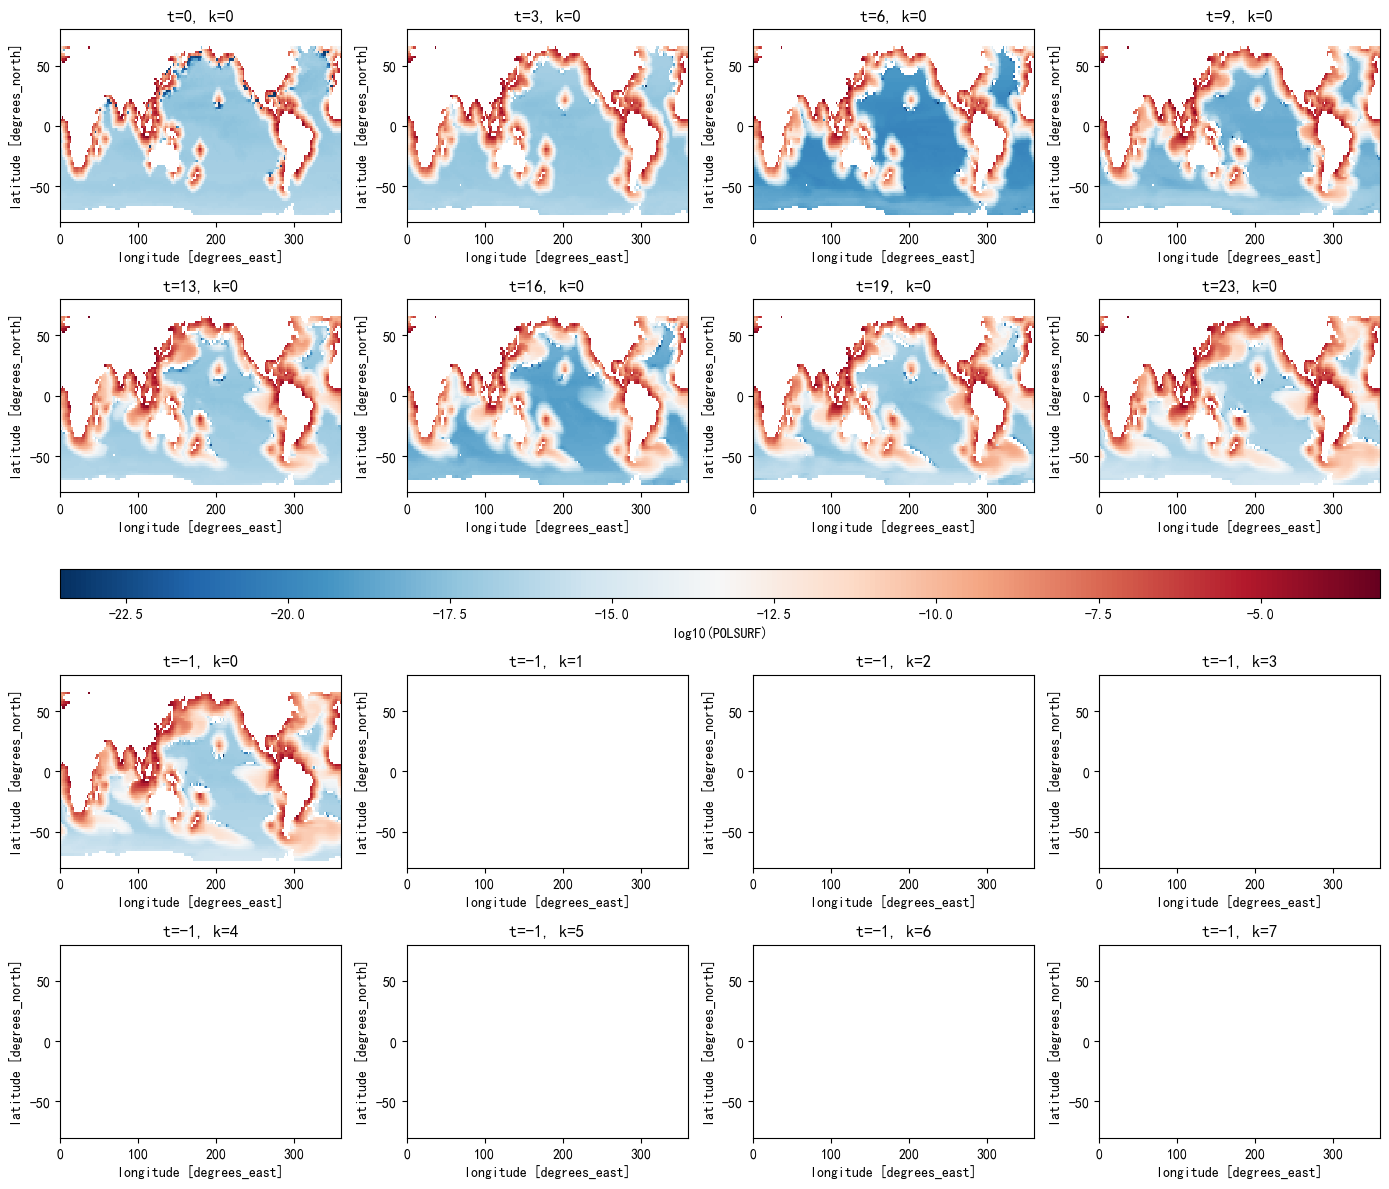

In [15]:
#表层 (k=1) 浓度 (`mol/m^3`)
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.POLSURF
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap='RdBu_r')
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap='RdBu_r')
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLSURF)")

plt.tight_layout()
plt.show()


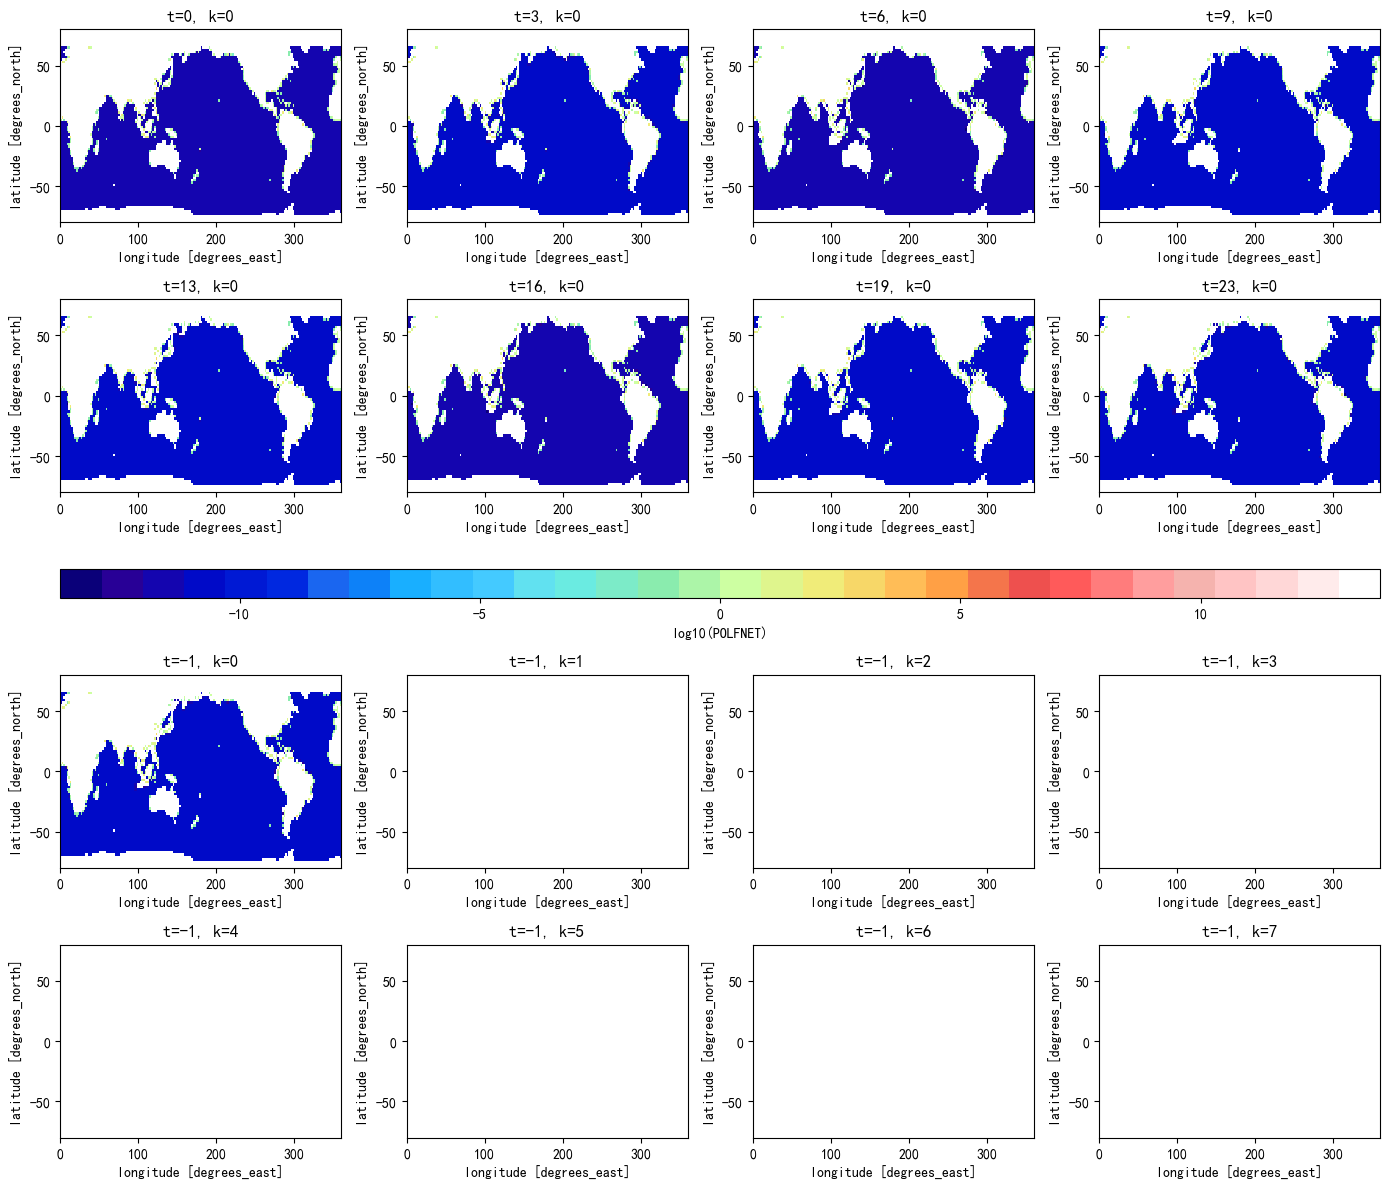

In [16]:
#表层净通量（排放 + 挥发 + 干/湿沉降）
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.POLFNET
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.GMT_haxby)
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.GMT_haxby)
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLFNET)")

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Volatilization flux (positive/negative log)')

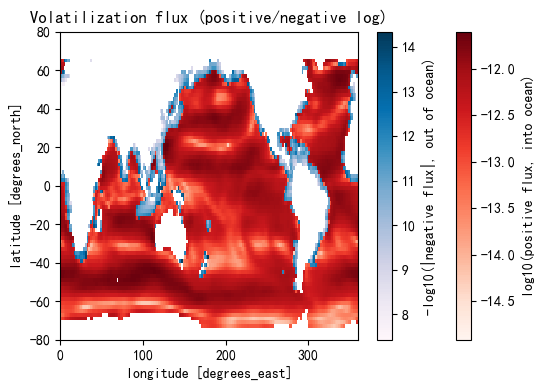

In [17]:
#挥发（气化）通量，正值表示入海。
import numpy as np
import matplotlib.pyplot as plt

da = ds.POLFVOL[-1, 0]
pos = da.where(da > 0)
neg = da.where(da < 0)
plt.figure(figsize=(6,4))
# 入海(正值) log10
p = np.log10(pos).plot(
    cmap=cmaps.MPL_Reds,
    add_colorbar=True
)
p.colorbar.set_label("log10(positive flux, into ocean)")

# 出海(负值) -log10(|flux|)
n = (-np.log10(-neg)).plot(
    cmap=cmaps.MPL_PuBu,
    add_colorbar=True
)
n.colorbar.set_label("-log10(|negative flux|, out of ocean)")
plt.title("Volatilization flux (positive/negative log)")

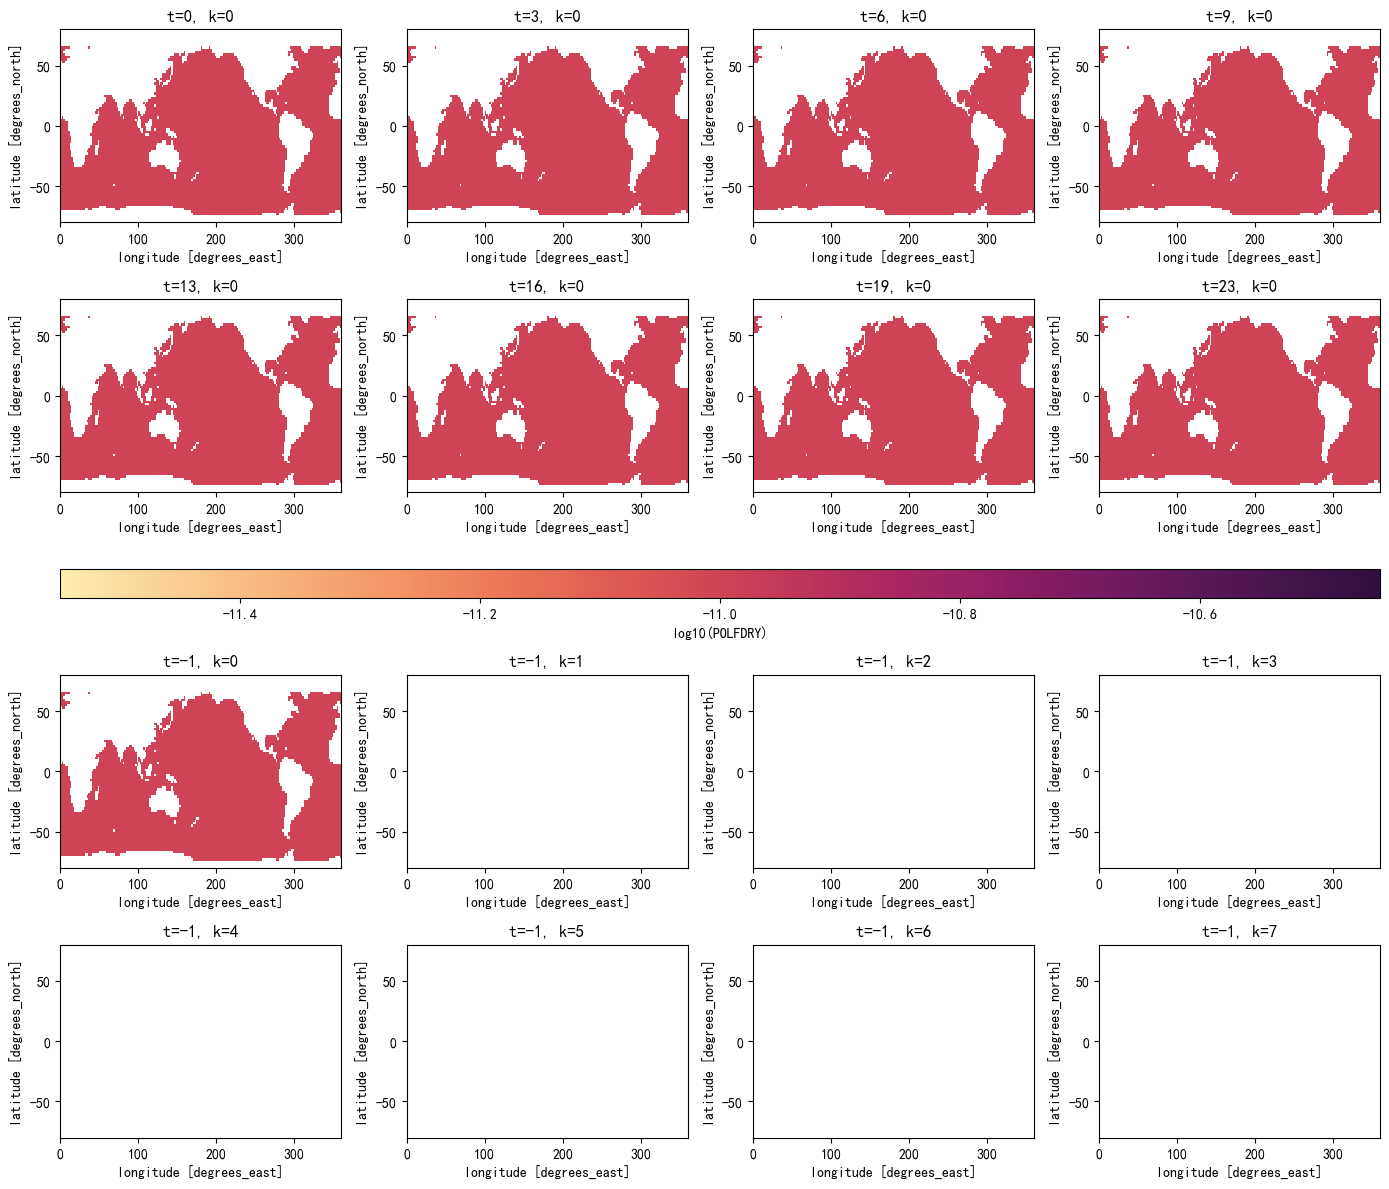

In [18]:
#干沉降通量。
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.POLFDRY
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.cmocean_matter)
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap=cmaps.cmocean_matter)
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLFDRY)")

plt.tight_layout()
plt.show()


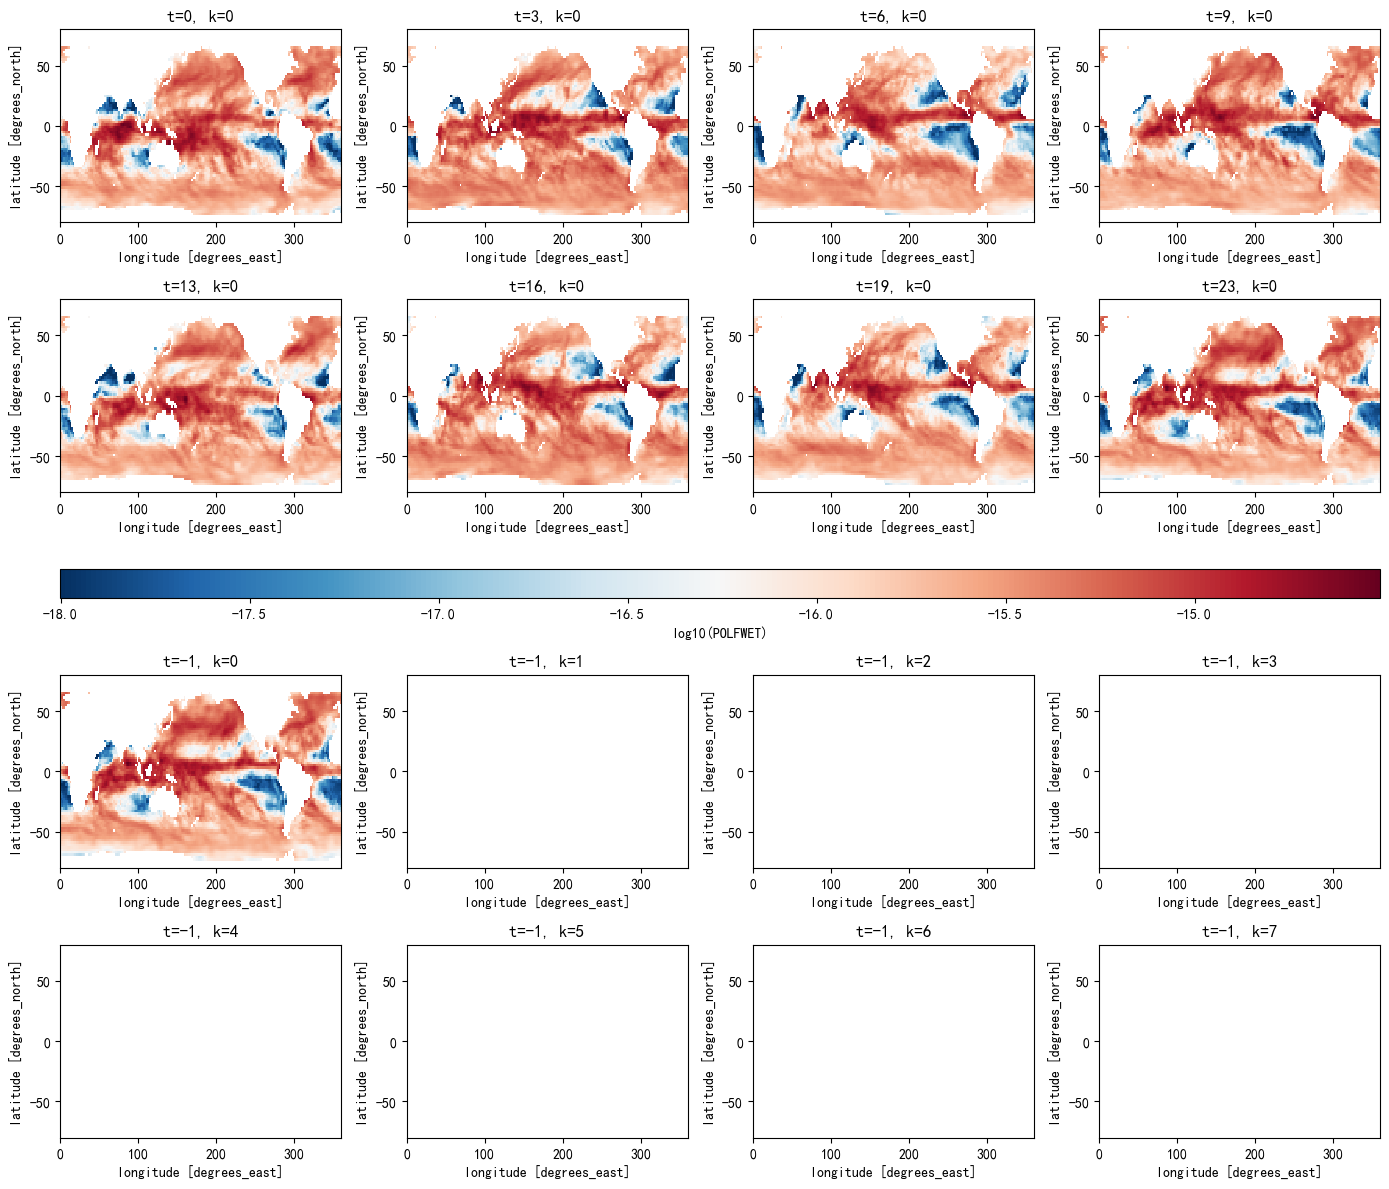

In [19]:
#湿沉降通量。
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
var = ds.POLFWET
nt = var.sizes[var.dims[0]]
nz = var.sizes[var.dims[1]]
time_idx = np.linspace(0, nt-1, 8, dtype=int)
depth_idx = np.arange(8)

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 4, height_ratios=[1,1,0.15,1,1])  # 第3行很窄

axes = []
# 第一、二行：前8个
for i, t in enumerate(time_idx):
    row = 0 if i < 4 else 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: t, var.dims[1]: 0})
    da_log = np.log10(da.where(da > 0))
    im = da_log.plot(ax=ax, add_colorbar=False, cmap='RdBu_r')
    ax.set_title(f"t={t}, k=0")
    axes.append(ax)

# 第4、5行：后8个
for j, k in enumerate(depth_idx):
    row = 3 if j < 4 else 4
    col = j % 4
    ax = fig.add_subplot(gs[row, col])
    da = var.isel({var.dims[0]: -1, var.dims[1]: k})
    da_log = np.log10(da.where(da > 0))
    da_log.plot(ax=ax, add_colorbar=False, cmap='RdBu_r')
    ax.set_title(f"t=-1, k={k}")
    axes.append(ax)

# colorbar 置于第3行
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("log10(POLFWET)")

plt.tight_layout()
plt.show()


In [38]:
#写为nc文件
ds.to_netcdf('rugkeytest_20251030_output.nc')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

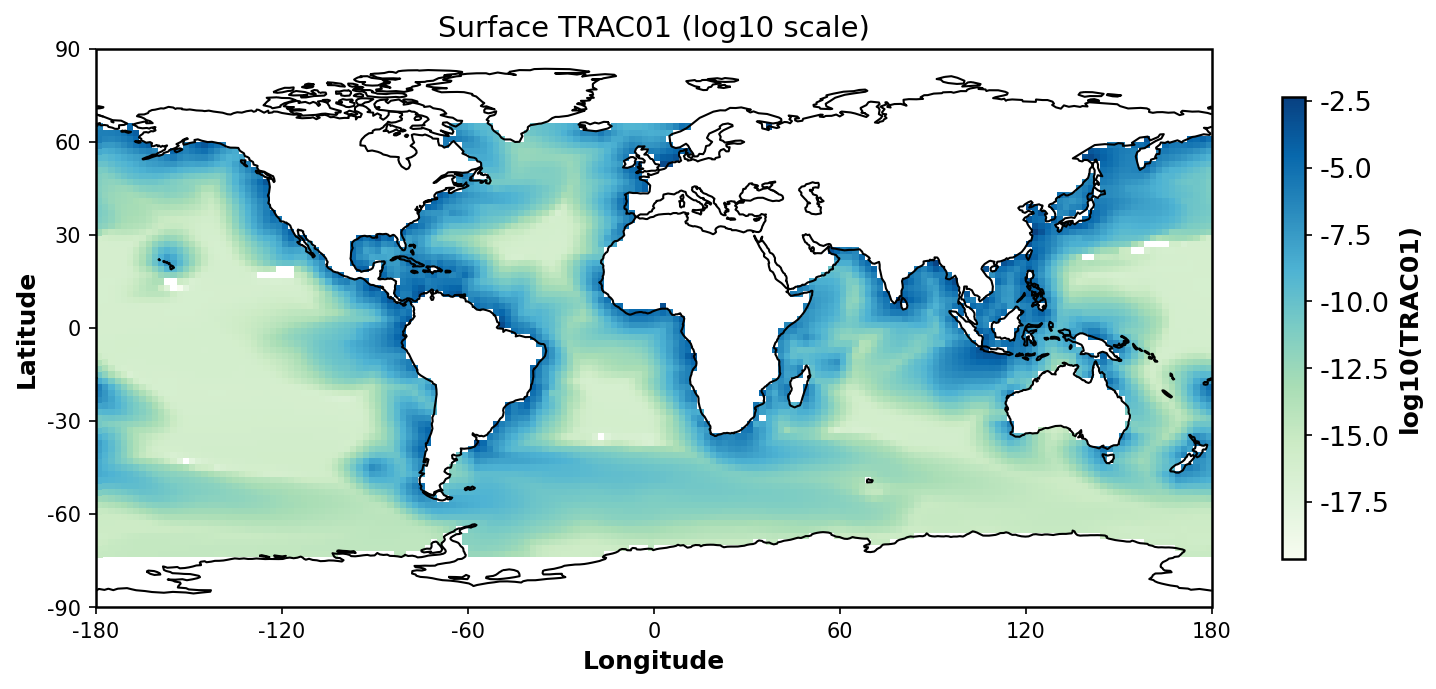

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 数据
#da = ds.TRAC01.where(ds.TRAC01 != 0)[-1, 0]
#da_log = np.log10(da.where(da > 0))

da_last12 = ds.TRAC01.where(ds.TRAC01 != 0)[-12:, 0, :, :]

# 沿时间维度做平均
da_mean = 5*da_last12.mean(dim='time')
da_log = np.log10(da_mean.where(da_mean > 0))

# 建图
plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 主图
mesh = ax.pcolormesh(
    da['XC'], da['YC'], da_log,
    cmap='GnBu',
    shading='auto',
    transform=ccrs.PlateCarree()
)

# 海岸线
ax.coastlines()

# -------------------------
# 坐标轴刻度与标签（新增）
# -------------------------
# 设置经纬度刻度
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

# 打印刻度标签
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# 加刻度框线
ax.tick_params(labelsize=10)

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, shrink=0.8,orientation='horizontal',fraction=0.05)
cbar.set_label("log10(TRAC01)", fontsize=12)

# 标题
ax.set_title("Surface TRAC01 (log10 scale)", fontsize=14)

plt.show()
